# Metrics Comparison Histogram Analysis

This notebook loads the benchmark metrics comparison data and creates histograms to visualize the distribution of performance and RDF metrics across different generators.

## 1. Import Required Libraries

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## 2. Load CSV Data

In [10]:
# Load the metrics comparison CSV
df = pd.read_csv('metrics_comparison.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst few rows:")
df.head()

Dataset Shape: (16, 14)

Column Names:
['Generator', 'Run_ID', 'Perf_Throughput', 'Perf_Total_Triples', 'Perf_Execution_Time', 'RDF_Triples', 'RDF_Subjects', 'RDF_Predicates', 'RDF_Objects', 'RDF_Classes', 'RDF_Mean_Outdegree', 'RDF_Mean_Indegree', 'RDF_Coherence', 'RDF_Type_Coverage_Avg']

First few rows:


,Generator,Run_ID,Perf_Throughput,Perf_Total_Triples,Perf_Execution_Time,RDF_Triples,RDF_Subjects,RDF_Predicates,RDF_Objects,RDF_Classes,RDF_Mean_Outdegree,RDF_Mean_Indegree,RDF_Coherence,RDF_Type_Coverage_Avg
0,BSBM_HIGH_COHERENCE,run_1,98973.336853,374911,3.788000,374911,36433,40,86200,158,10.290424,4.349316,0.952629,0.840652
1,BSBM_LOW_COHERENCE,run_1,100485.392656,374911,3.731000,374911,36433,40,86200,158,10.290424,4.349316,0.952629,0.840652
2,GAIA_LUBM_HIGH_COHERENCE,run_1,345574.638390,1290000,4.460544,1541451,430095,32,131313,50,3.583978,11.738754,0.390792,0.589244
3,GAIA_LUBM_LOW_COHERENCE,run_1,297808.257427,1290000,3.328145,991149,430095,32,131011,50,2.304489,7.565388,0.324206,0.604608
4,LINKGEN_LUBM_HIGH_COHERENCE,run_1,429161.417323,6268,0.254000,109007,9010,460,740,448,12.098446,147.306757,0.676539,0.986241


## 3. Data Preprocessing

In [11]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Extract coherence level (HIGH/LOW) from Generator name
df['Coherence_Level'] = df['Generator'].apply(lambda x: 'HIGH' if 'HIGH' in x else 'LOW')

# Extract base generator name (without coherence suffix)
df['Base_Generator'] = df['Generator'].apply(lambda x: x.replace('_HIGH_COHERENCE', '').replace('_LOW_COHERENCE', ''))

# Display summary statistics
print("\nSummary Statistics:")
df.describe()

Missing Values:
Generator                0
Run_ID                   0
Perf_Throughput          0
Perf_Total_Triples       0
Perf_Execution_Time      0
RDF_Triples              0
RDF_Subjects             0
RDF_Predicates           0
RDF_Objects              0
RDF_Classes              0
RDF_Mean_Outdegree       0
RDF_Mean_Indegree        0
RDF_Coherence            0
RDF_Type_Coverage_Avg    0
dtype: int64

Summary Statistics:


,Perf_Throughput,Perf_Total_Triples,Perf_Execution_Time,RDF_Triples,RDF_Subjects,RDF_Predicates,RDF_Objects,RDF_Classes,RDF_Mean_Outdegree,RDF_Mean_Indegree,RDF_Coherence,RDF_Type_Coverage_Avg
count,16.000000,1.600000e+01,16.000000,1.600000e+01,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000
mean,141821.563847,4.181794e+05,5.646142,4.715978e+05,105544.875000,78.812500,73256.562500,95.937500,6.455233,24.220307,0.767996,0.831979
std,164904.987912,4.872027e+05,6.652936,5.377665e+05,146825.061672,149.117054,82096.771059,145.184236,3.176483,48.115068,0.249055,0.184339
min,2590.000000,3.652000e+03,0.254000,6.185000e+03,1750.000000,14.000000,740.000000,15.000000,2.304489,2.149336,0.324206,0.473393
25%,29829.734233,7.619200e+04,2.876402,1.087055e+05,20907.250000,17.000000,11801.500000,15.000000,3.773585,4.650117,0.621347,0.747024
50%,49484.613271,1.806310e+05,3.759500,1.806310e+05,25918.000000,25.000000,33570.000000,32.500000,6.133843,7.600500,0.877095,0.894469
75%,289252.057854,6.350262e+05,5.012859,6.977872e+05,175214.000000,37.750000,131086.500000,78.500000,7.920030,8.775246,0.960084,0.986902
max,475794.031773,1.316322e+06,28.335000,1.541451e+06,430095.000000,460.000000,278914.000000,448.000000,12.098446,147.306757,0.998148,0.996667


## 4. Create Histograms for Performance Metrics

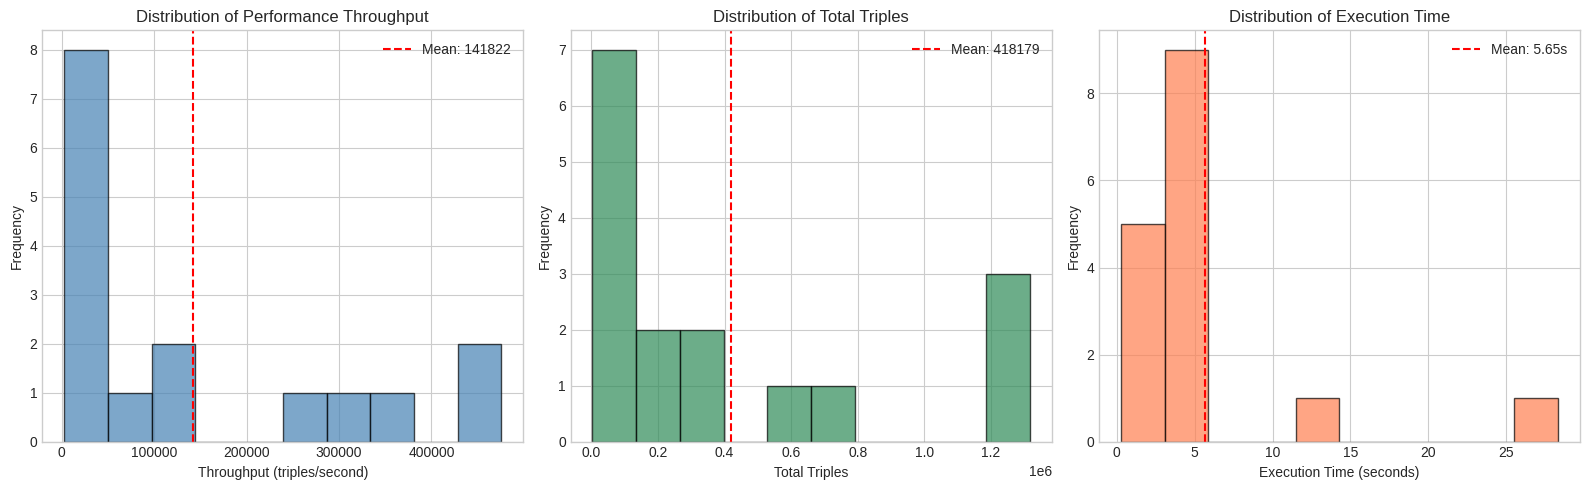

In [12]:
# Create histograms for Performance Metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Throughput histogram
axes[0].hist(df['Perf_Throughput'], bins=10, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Throughput (triples/second)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Performance Throughput')
axes[0].axvline(df['Perf_Throughput'].mean(), color='red', linestyle='--', label=f'Mean: {df["Perf_Throughput"].mean():.0f}')
axes[0].legend()

# Total Triples histogram
axes[1].hist(df['Perf_Total_Triples'], bins=10, edgecolor='black', alpha=0.7, color='seagreen')
axes[1].set_xlabel('Total Triples')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Total Triples')
axes[1].axvline(df['Perf_Total_Triples'].mean(), color='red', linestyle='--', label=f'Mean: {df["Perf_Total_Triples"].mean():.0f}')
axes[1].legend()

# Execution Time histogram
axes[2].hist(df['Perf_Execution_Time'], bins=10, edgecolor='black', alpha=0.7, color='coral')
axes[2].set_xlabel('Execution Time (seconds)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Distribution of Execution Time')
axes[2].axvline(df['Perf_Execution_Time'].mean(), color='red', linestyle='--', label=f'Mean: {df["Perf_Execution_Time"].mean():.2f}s')
axes[2].legend()

plt.tight_layout()
plt.show()

## 5. Create Histograms for RDF Metrics

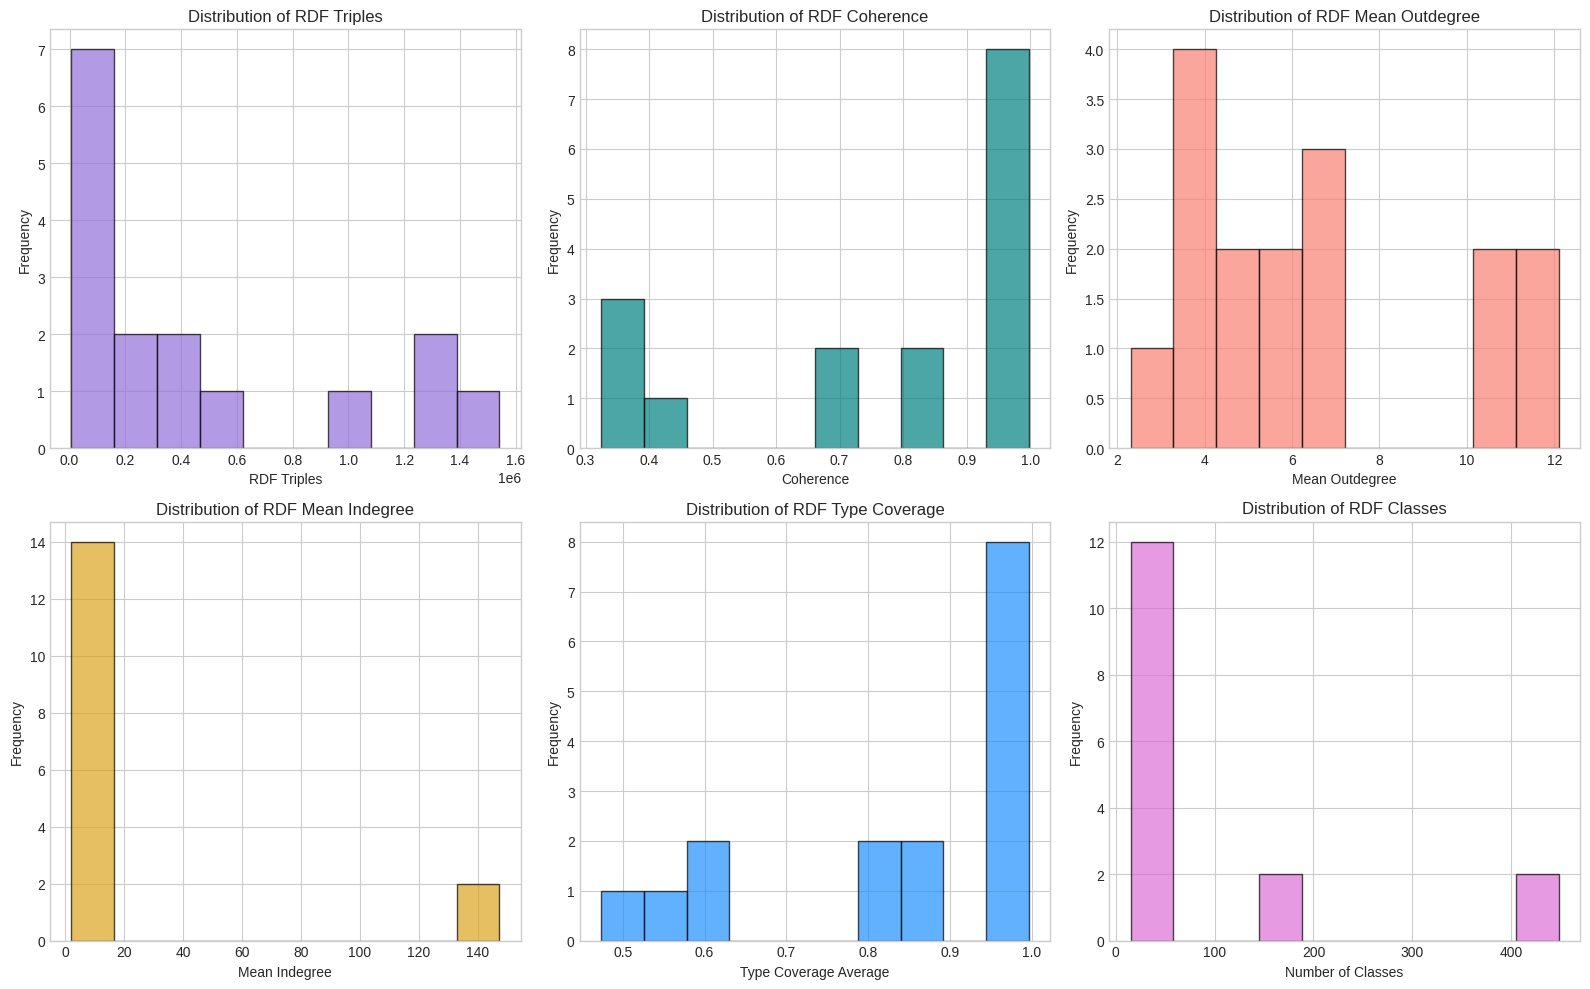

In [13]:
# Create histograms for RDF Metrics
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# RDF Triples histogram
axes[0, 0].hist(df['RDF_Triples'], bins=10, edgecolor='black', alpha=0.7, color='mediumpurple')
axes[0, 0].set_xlabel('RDF Triples')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of RDF Triples')

# RDF Coherence histogram
axes[0, 1].hist(df['RDF_Coherence'], bins=10, edgecolor='black', alpha=0.7, color='teal')
axes[0, 1].set_xlabel('Coherence')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of RDF Coherence')

# RDF Mean Outdegree histogram
axes[0, 2].hist(df['RDF_Mean_Outdegree'], bins=10, edgecolor='black', alpha=0.7, color='salmon')
axes[0, 2].set_xlabel('Mean Outdegree')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Distribution of RDF Mean Outdegree')

# RDF Mean Indegree histogram
axes[1, 0].hist(df['RDF_Mean_Indegree'], bins=10, edgecolor='black', alpha=0.7, color='goldenrod')
axes[1, 0].set_xlabel('Mean Indegree')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of RDF Mean Indegree')

# RDF Type Coverage histogram
axes[1, 1].hist(df['RDF_Type_Coverage_Avg'], bins=10, edgecolor='black', alpha=0.7, color='dodgerblue')
axes[1, 1].set_xlabel('Type Coverage Average')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of RDF Type Coverage')

# RDF Classes histogram
axes[1, 2].hist(df['RDF_Classes'], bins=10, edgecolor='black', alpha=0.7, color='orchid')
axes[1, 2].set_xlabel('Number of Classes')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('Distribution of RDF Classes')

plt.tight_layout()
plt.show()

## 6. Create Grouped Histograms by Generator

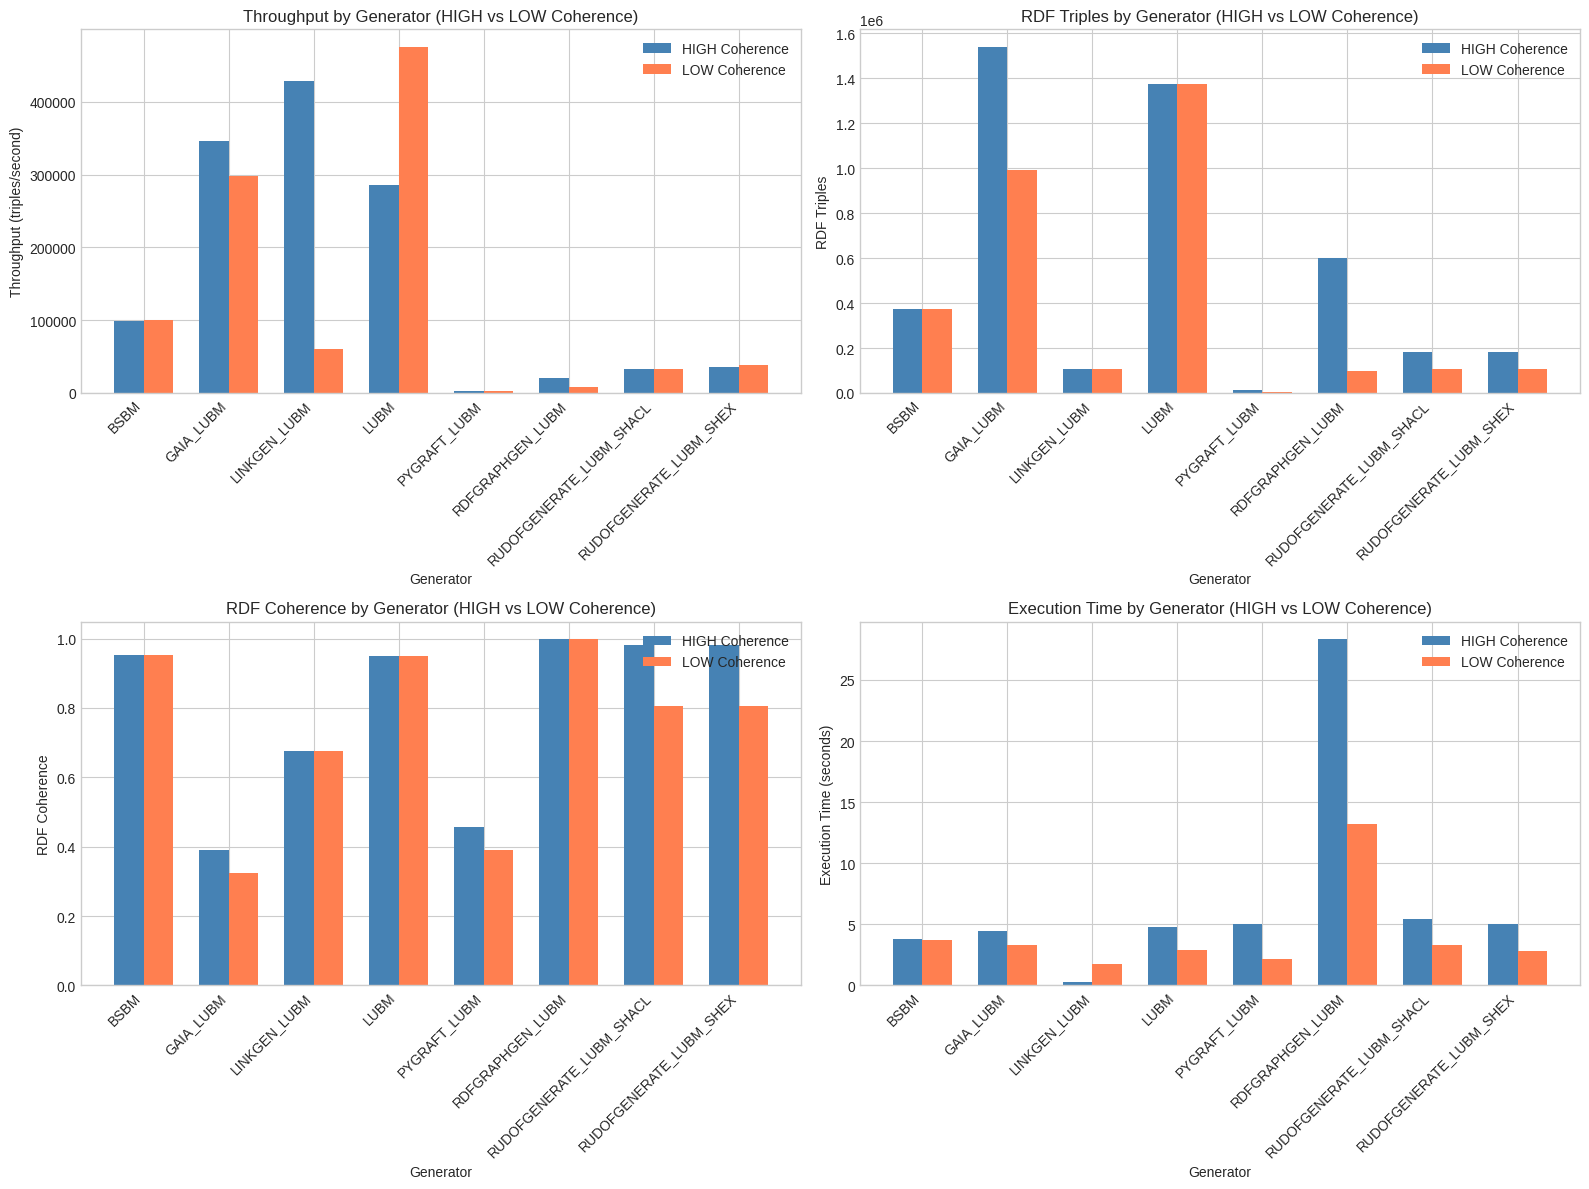

In [14]:
# Grouped bar chart comparing Throughput by Generator
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Define colors for HIGH and LOW coherence
colors = {'HIGH': 'steelblue', 'LOW': 'coral'}

# Plot 1: Throughput by Generator
x = np.arange(len(df['Base_Generator'].unique()))
width = 0.35
generators = df['Base_Generator'].unique()

high_throughput = df[df['Coherence_Level'] == 'HIGH'].set_index('Base_Generator')['Perf_Throughput']
low_throughput = df[df['Coherence_Level'] == 'LOW'].set_index('Base_Generator')['Perf_Throughput']

bars1 = axes[0, 0].bar(x - width/2, [high_throughput.get(g, 0) for g in generators], width, label='HIGH Coherence', color=colors['HIGH'])
bars2 = axes[0, 0].bar(x + width/2, [low_throughput.get(g, 0) for g in generators], width, label='LOW Coherence', color=colors['LOW'])
axes[0, 0].set_xlabel('Generator')
axes[0, 0].set_ylabel('Throughput (triples/second)')
axes[0, 0].set_title('Throughput by Generator (HIGH vs LOW Coherence)')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(generators, rotation=45, ha='right')
axes[0, 0].legend()

# Plot 2: RDF Triples by Generator
high_triples = df[df['Coherence_Level'] == 'HIGH'].set_index('Base_Generator')['RDF_Triples']
low_triples = df[df['Coherence_Level'] == 'LOW'].set_index('Base_Generator')['RDF_Triples']

axes[0, 1].bar(x - width/2, [high_triples.get(g, 0) for g in generators], width, label='HIGH Coherence', color=colors['HIGH'])
axes[0, 1].bar(x + width/2, [low_triples.get(g, 0) for g in generators], width, label='LOW Coherence', color=colors['LOW'])
axes[0, 1].set_xlabel('Generator')
axes[0, 1].set_ylabel('RDF Triples')
axes[0, 1].set_title('RDF Triples by Generator (HIGH vs LOW Coherence)')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(generators, rotation=45, ha='right')
axes[0, 1].legend()

# Plot 3: Coherence by Generator
high_coherence = df[df['Coherence_Level'] == 'HIGH'].set_index('Base_Generator')['RDF_Coherence']
low_coherence = df[df['Coherence_Level'] == 'LOW'].set_index('Base_Generator')['RDF_Coherence']

axes[1, 0].bar(x - width/2, [high_coherence.get(g, 0) for g in generators], width, label='HIGH Coherence', color=colors['HIGH'])
axes[1, 0].bar(x + width/2, [low_coherence.get(g, 0) for g in generators], width, label='LOW Coherence', color=colors['LOW'])
axes[1, 0].set_xlabel('Generator')
axes[1, 0].set_ylabel('RDF Coherence')
axes[1, 0].set_title('RDF Coherence by Generator (HIGH vs LOW Coherence)')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(generators, rotation=45, ha='right')
axes[1, 0].legend()

# Plot 4: Execution Time by Generator
high_exec_time = df[df['Coherence_Level'] == 'HIGH'].set_index('Base_Generator')['Perf_Execution_Time']
low_exec_time = df[df['Coherence_Level'] == 'LOW'].set_index('Base_Generator')['Perf_Execution_Time']

axes[1, 1].bar(x - width/2, [high_exec_time.get(g, 0) for g in generators], width, label='HIGH Coherence', color=colors['HIGH'])
axes[1, 1].bar(x + width/2, [low_exec_time.get(g, 0) for g in generators], width, label='LOW Coherence', color=colors['LOW'])
axes[1, 1].set_xlabel('Generator')
axes[1, 1].set_ylabel('Execution Time (seconds)')
axes[1, 1].set_title('Execution Time by Generator (HIGH vs LOW Coherence)')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(generators, rotation=45, ha='right')
axes[1, 1].legend()

plt.tight_layout()
plt.show()